# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [20]:
import urllib
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

host = os.getenv("PGHOST")
port = os.getenv("PGPORT")
database = os.getenv("PGDATABASE")
user = os.getenv("PGUSER")
password = os.getenv("PGPASSWORD")

password_enc = urllib.parse.quote_plus(password)


url = f"postgresql+psycopg2://{user}:{password_enc}@{host}:{port}/{database}"


engine = create_engine(url, connect_args={}, pool_pre_ping=True)

In [5]:
from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text
from sqlalchemy.exc import SQLAlchemyError

def test_connection() -> None:
    try:
        with engine.connect() as connection:
            database_name = connection.execute(
                text("SELECT current_database()")
            ).scalar_one()

            postgresql_version = connection.execute(
                text("SHOW server_version")
            ).scalar_one()

        print(f"Connected to database: {database_name}")
        print(f"PostgreSQL version: {postgresql_version}")

    except SQLAlchemyError as error:
        raise RuntimeError(
            "Could not connect to PostgreSQL. "
            "Check credentials, server address, port, SSL settings, "
            "and network access."
        ) from error

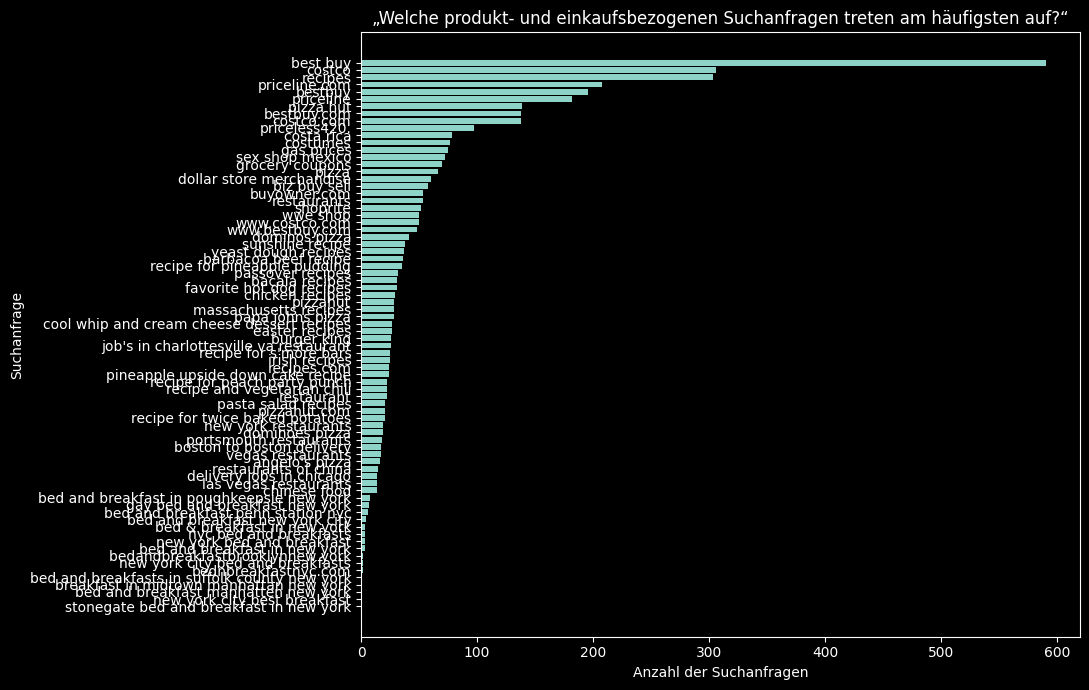

In [18]:
sql_query_1 = """
SELECT
    kombiniertes_wort AS suchanfrage,
    anzahl_suchen
FROM food_preferences.search_item
ORDER BY anzahl_suchen DESC;
"""

with engine.connect() as connection:
    produkt_suchen = pd.read_sql_query(
        text(sql_query_1),
        connection
    )

plot_data = produkt_suchen.sort_values(
    "anzahl_suchen"
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_data["suchanfrage"],
    plot_data["anzahl_suchen"]
)

plt.title("„Welche produkt- und einkaufsbezogenen Suchanfragen treten am häufigsten auf?“")
plt.xlabel("Anzahl der Suchanfragen")
plt.ylabel("Suchanfrage")
plt.tight_layout()
plt.show()

,search_query,search_count,category_name
0,pizza hut,139,Food Delivery
1,pizza,66,Food Delivery
2,restaurants,53,Food Delivery
3,dominos pizza,41,Food Delivery
4,papa johns pizza,28,Food Delivery
5,pizzahut,28,Food Delivery
6,job's in charlottesville va restaurant,26,Food Delivery
7,burger king,26,Food Delivery
8,restaurant,22,Food Delivery
9,pizzahut.com,21,Food Delivery


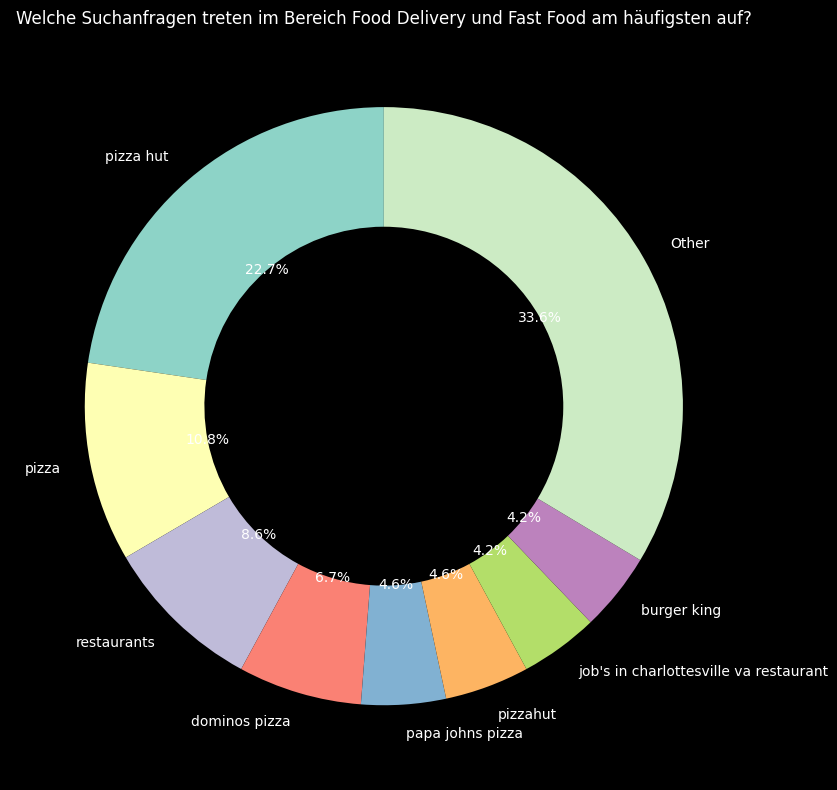

In [19]:
sql_query_2 = """
SELECT
    search_item.kombiniertes_wort AS search_query,
    search_item.anzahl_suchen AS search_count,
    search_category.category_name
FROM food_preferences.search_item
JOIN food_preferences.search_category
    ON search_item.cat_id = search_category.cat_id
WHERE search_category.service_type = 'delivery'
ORDER BY search_item.anzahl_suchen DESC;
"""

with engine.connect() as connection:
    delivery_searches = pd.read_sql_query(
        text(sql_query_2),
        connection
    )

display(delivery_searches)

if delivery_searches.empty:
    print("No delivery searches found.")

else:
    top_searches = delivery_searches.head(8).copy()
    other_count = delivery_searches.iloc[8:]["search_count"].sum()

    if other_count > 0:
        other_row = pd.DataFrame({
            "search_query": ["Other"],
            "search_count": [other_count]
        })

        chart_data = pd.concat(
            [top_searches, other_row],
            ignore_index=True
        )
    else:
        chart_data = top_searches

    plt.figure(figsize=(10, 8))

    plt.pie(
        chart_data["search_count"],
        labels=chart_data["search_query"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.4}
    )

    plt.title("Welche Suchanfragen treten im Bereich Food Delivery und Fast Food am häufigsten auf?")
    plt.tight_layout()
    plt.show()

,search_query,search_count,category_name
0,recipes,303,Recipe and Cooking
1,sunshine recipe,38,Recipe and Cooking
2,yeast dough recipes,37,Recipe and Cooking
3,barbacoa beef recipe,36,Recipe and Cooking
4,recipe for pineapple pudding,35,Recipe and Cooking
5,passover recipes,32,Recipe and Cooking
6,bacala recipes,31,Recipe and Cooking
7,favorite hot dog recipes,31,Recipe and Cooking
8,chicken recipes,29,Recipe and Cooking
9,massachusetts recipes,28,Recipe and Cooking


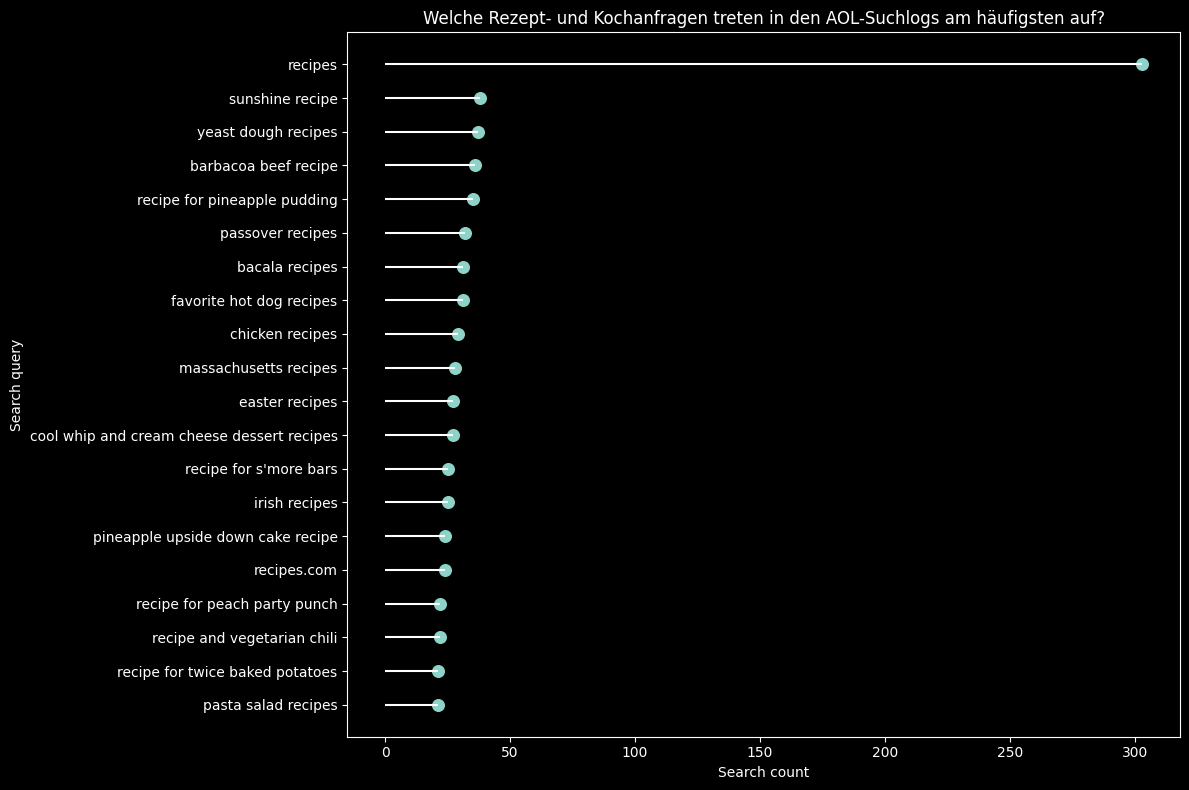

In [20]:
sql_query_3 = """
SELECT
    search_item.kombiniertes_wort AS search_query,
    search_item.anzahl_suchen AS search_count,
    search_category.category_name
FROM food_preferences.search_item
JOIN food_preferences.search_category
    ON search_item.cat_id = search_category.cat_id
WHERE search_category.service_type = 'recipe'
ORDER BY search_item.anzahl_suchen DESC;
"""

with engine.connect() as connection:
    recipe_searches = pd.read_sql_query(
        text(sql_query_3),
        connection
    )

display(recipe_searches)

plot_data = recipe_searches.sort_values(
    "search_count",
    ascending=True
)

plt.figure(figsize=(12, 8))

plt.hlines(
    y=plot_data["search_query"],
    xmin=0,
    xmax=plot_data["search_count"]
)

plt.scatter(
    plot_data["search_count"],
    plot_data["search_query"],
    s=70
)

plt.title("Welche Rezept- und Kochanfragen treten in den AOL-Suchlogs am häufigsten auf?")
plt.xlabel("Search count")
plt.ylabel("Search query")
plt.tight_layout()
plt.show()

,search_query,search_count,category_name
0,bed and breakfast in poughkeepsie new york,8,New York Breakfast Searches
1,gay bed and breakfast new york,7,New York Breakfast Searches
2,bed and breakfast penn station nyc,6,New York Breakfast Searches
3,bed and breakfast new york city,4,New York Breakfast Searches
4,bed & breakfast in new york,3,New York Breakfast Searches
5,nyc bed and breakfasts,3,New York Breakfast Searches
6,new york bed and breakfast,3,New York Breakfast Searches
7,bed and breakfast in new york,3,New York Breakfast Searches
8,bedandbreakfastbrooklynnew york,2,New York Breakfast Searches
9,bednbreakfastnyc.com,2,New York Breakfast Searches


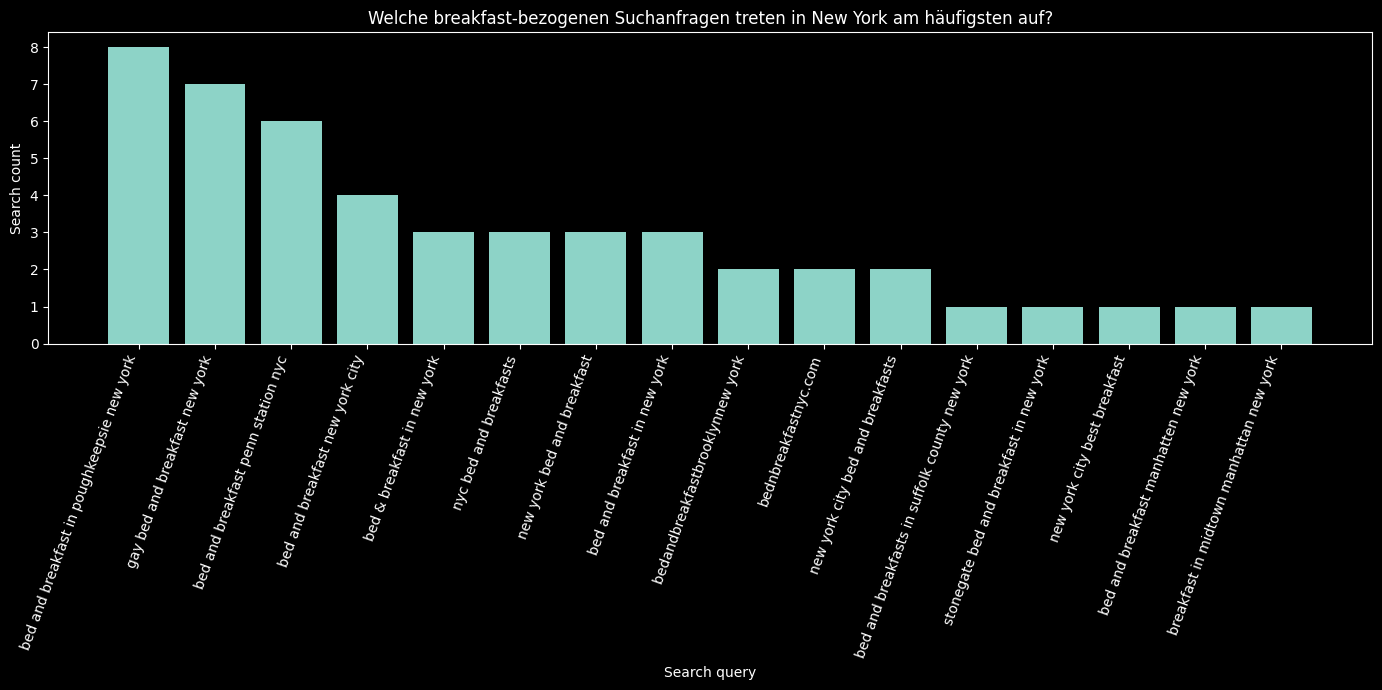

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

sql_query_4 = """
SELECT
    search_item.kombiniertes_wort AS search_query,
    search_item.anzahl_suchen AS search_count,
    search_category.category_name
FROM food_preferences.search_item
JOIN food_preferences.search_category
    ON search_item.cat_id = search_category.cat_id
WHERE search_category.service_type = 'breakfast'
ORDER BY search_item.anzahl_suchen DESC;
"""

with engine.connect() as connection:
    breakfast_searches = pd.read_sql_query(
        text(sql_query_4),
        connection
    )

display(breakfast_searches)

plt.figure(figsize=(14, 7))

plt.bar(
    breakfast_searches["search_query"],
    breakfast_searches["search_count"]
)

plt.title("Welche breakfast-bezogenen Suchanfragen treten in New York am häufigsten auf?")
plt.xlabel("Search query")
plt.ylabel("Search count")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

,month,state_name,search_count
0,2006-03-01,California,14
1,2006-03-01,Florida,7
2,2006-04-01,California,7
3,2006-04-01,Florida,12
4,2006-05-01,California,1
5,2006-05-01,Florida,18


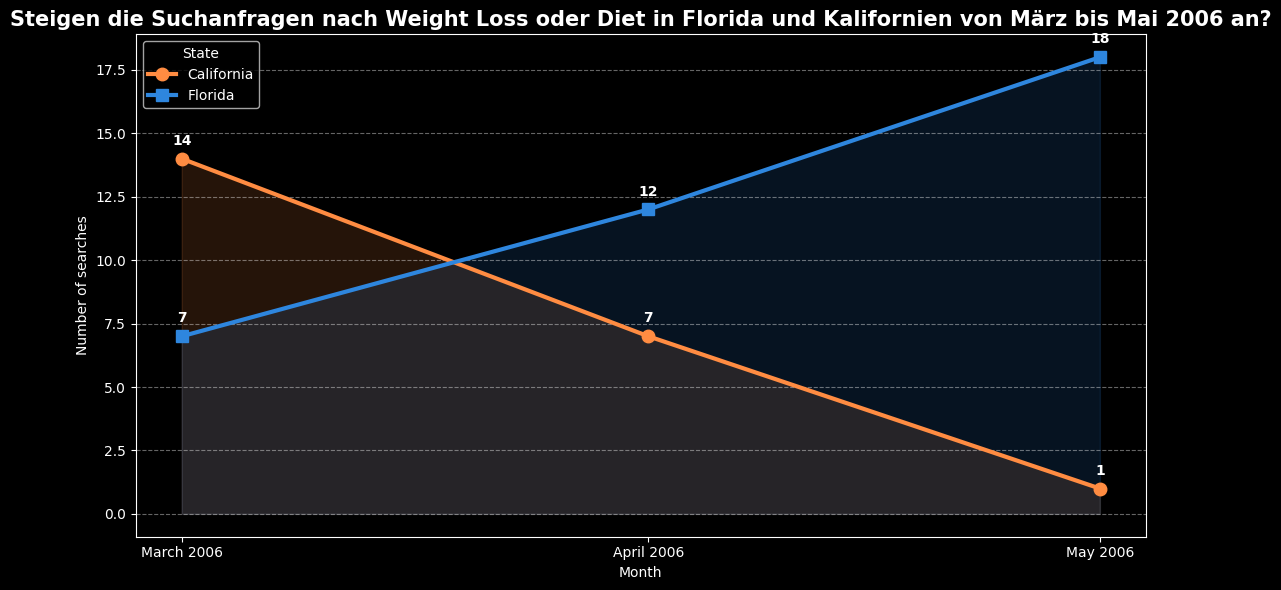

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

sql_query_5 = """
SELECT
    DATE_TRUNC('month', search_trend.search_date)::date AS month,
    search_trend.state_name,
    SUM(search_trend.search_count) AS search_count
FROM food_preferences.search_trend
JOIN food_preferences.search_category
    ON search_trend.cat_id = search_category.cat_id
WHERE search_category.service_type = 'health'
GROUP BY
    DATE_TRUNC('month', search_trend.search_date),
    search_trend.state_name
ORDER BY month, state_name;
"""

with engine.connect() as connection:
    diet_trends = pd.read_sql_query(
        text(sql_query_5),
        connection,
        parse_dates=["month"]
    )

display(diet_trends)

colors = {
    "California": "#FF8C42",
    "Florida": "#2E86DE"
}

markers = {
    "California": "o",
    "Florida": "s"
}

plt.figure(figsize=(11, 6))

for state in diet_trends["state_name"].unique():
    state_data = diet_trends[
        diet_trends["state_name"] == state
    ].sort_values("month")

    plt.plot(
        state_data["month"],
        state_data["search_count"],
        marker=markers.get(state, "o"),
        markersize=9,
        linewidth=3,
        color=colors.get(state),
        label=state
    )

    plt.fill_between(
        state_data["month"],
        state_data["search_count"],
        alpha=0.15,
        color=colors.get(state)
    )

    for _, row in state_data.iterrows():
        plt.annotate(
            str(row["search_count"]),
            (row["month"], row["search_count"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

plt.title(
    "Steigen die Suchanfragen nach Weight Loss oder Diet in Florida und Kalifornien von März bis Mai 2006 an?",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of searches")

plt.xticks(
    diet_trends["month"].drop_duplicates(),
    ["March 2006", "April 2006", "May 2006"]
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="State",
    frameon=True
)

plt.tight_layout()
plt.show()

,hour_of_day,search_count,category_name
0,0,4126,Food Searches by Hour
1,1,2553,Food Searches by Hour
2,2,1740,Food Searches by Hour
3,3,1033,Food Searches by Hour
4,4,700,Food Searches by Hour
5,5,684,Food Searches by Hour
6,6,1113,Food Searches by Hour
7,7,2329,Food Searches by Hour
8,8,3804,Food Searches by Hour
9,9,5434,Food Searches by Hour


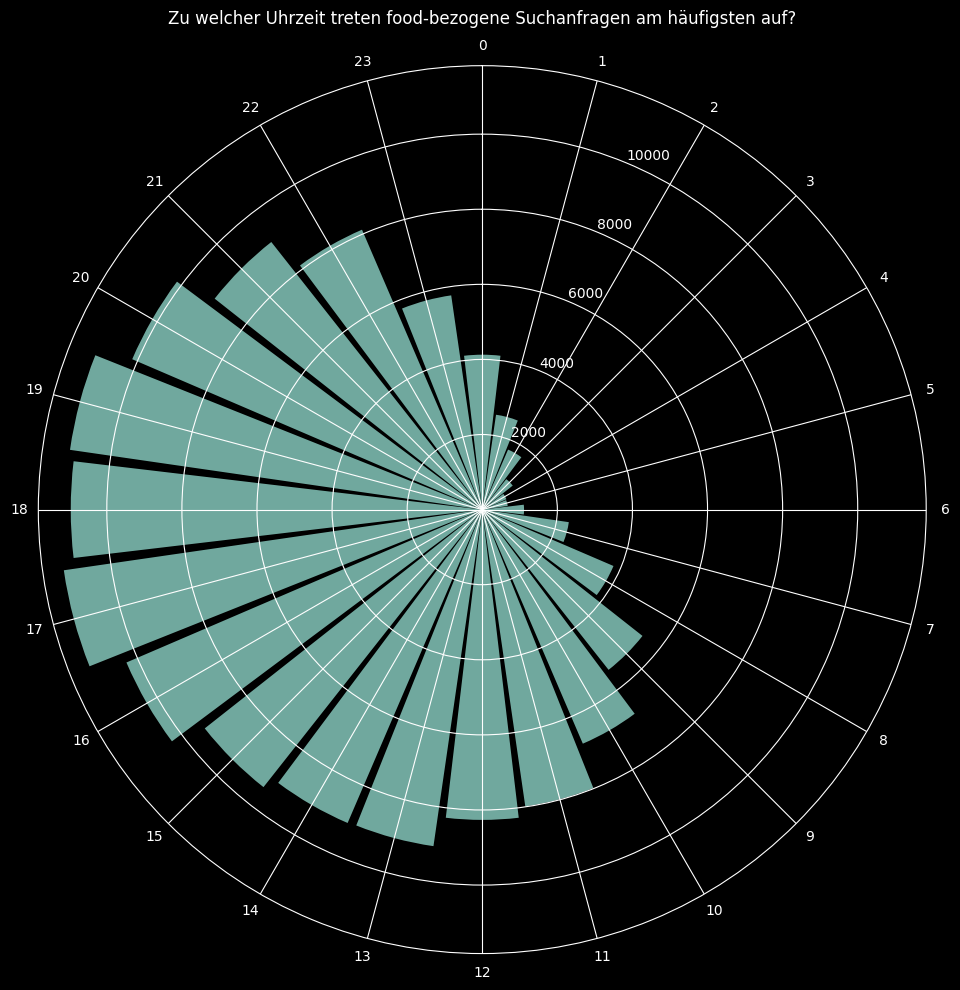

In [24]:
sql_query_7 = """
SELECT
    search_hourly.hour_of_day,
    search_hourly.search_count,
    search_category.category_name
FROM food_preferences.search_hourly
JOIN food_preferences.search_category
    ON search_hourly.cat_id = search_category.cat_id
WHERE search_category.service_type = 'food_time'
ORDER BY search_hourly.hour_of_day;
"""

with engine.connect() as connection:
    hourly_food_searches = pd.read_sql_query(
        text(sql_query_7),
        connection
    )

display(hourly_food_searches)

angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
values = hourly_food_searches["search_count"].values
width = 2 * np.pi / 24 * 0.9

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

bars = ax.bar(
    angles,
    values,
    width=width,
    alpha=0.8
)

ax.set_xticks(angles)
ax.set_xticklabels(hourly_food_searches["hour_of_day"].astype(str))

ax.set_title(
    "Zu welcher Uhrzeit treten food-bezogene Suchanfragen am häufigsten auf?",
    pad=30
)

plt.tight_layout()
plt.show()

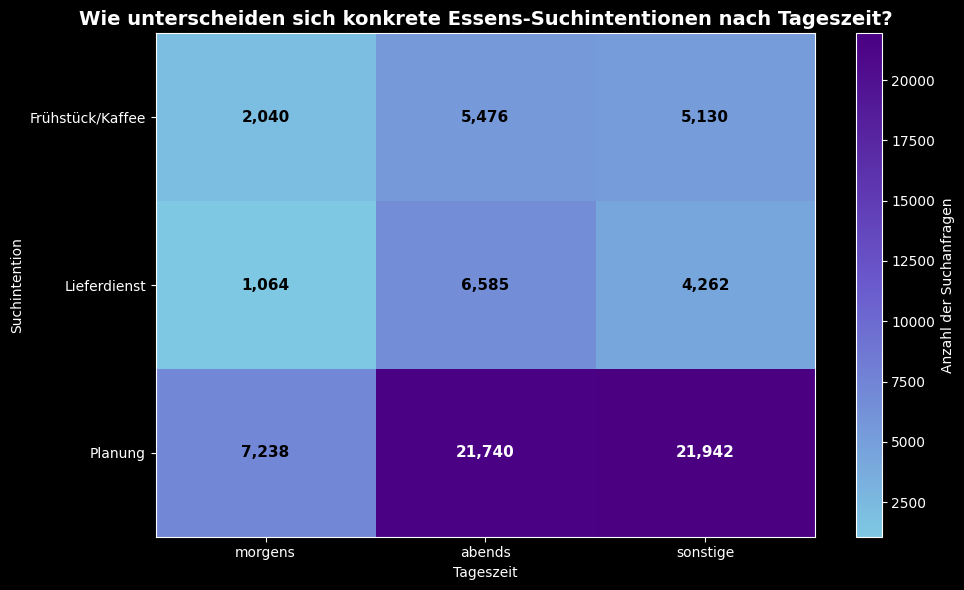

In [29]:
sql_query_8 = """
SELECT
    time_period.period_name,
    search_category.category_name AS intention,
    eating_pattern.search_count
FROM food_preferences.eating_pattern
JOIN food_preferences.time_period
    ON eating_pattern.time_id = time_period.time_id
JOIN food_preferences.search_category
    ON eating_pattern.cat_id = search_category.cat_id
WHERE search_category.category_name <> 'Sonstiges'
ORDER BY
    time_period.period_name,
    eating_pattern.search_count DESC;
"""

with engine.connect() as connection:
    eating_patterns = pd.read_sql_query(
        text(sql_query_8),
        connection
    )

heatmap_data = eating_patterns.pivot(
    index="intention",
    columns="period_name",
    values="search_count"
).fillna(0)

heatmap_data = heatmap_data.reindex(
    columns=["morgens", "abends", "sonstige"]
)

plt.figure(figsize=(10, 6))
blue_purple = LinearSegmentedColormap.from_list(
    "blue_purple",
    ["#7EC8E3", "#6A5ACD", "#4B0082"]
)

image = plt.imshow(
    heatmap_data,
    cmap=blue_purple,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

# Text color changes depending on background brightness
threshold = heatmap_data.values.max() * 0.55

for row in range(len(heatmap_data.index)):
    for column in range(len(heatmap_data.columns)):
        value = int(heatmap_data.iloc[row, column])

        text_color = "white" if value > threshold else "black"

        plt.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontweight="bold",
            fontsize=11
        )

plt.colorbar(
    image,
    label="Anzahl der Suchanfragen"
)

plt.title(
    "Wie unterscheiden sich konkrete Essens-Suchintentionen nach Tageszeit?",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tageszeit")
plt.ylabel("Suchintention")
plt.tight_layout()
plt.show()

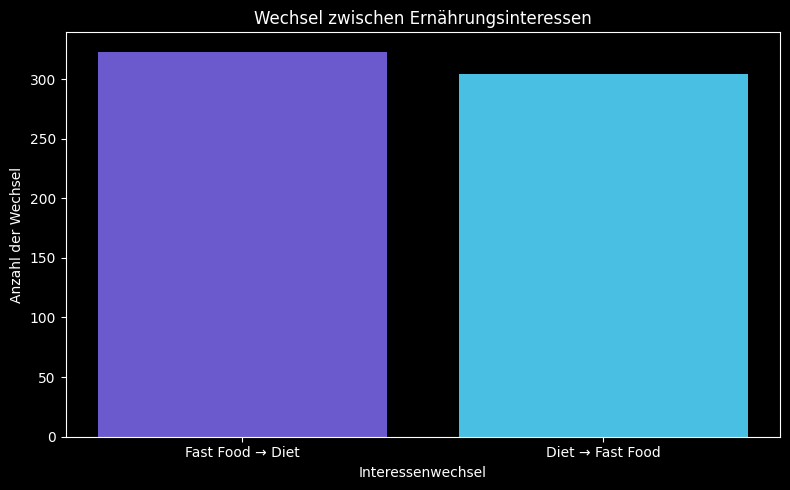

In [6]:
sql_query_9 = """
SELECT
    previous.category_name AS previous_interest,
    new.category_name AS new_interest,
    interest_transition.switch_count
FROM food_preferences.interest_transition

JOIN food_preferences.search_category AS previous
    ON interest_transition.prev_cat_id = previous.cat_id

JOIN food_preferences.search_category AS new
    ON interest_transition.new_cat_id = new.cat_id

ORDER BY interest_transition.switch_count DESC;
"""

with engine.connect() as connection:
    interest_changes = pd.read_sql_query(
        text(sql_query_9),
        connection
    )

interest_changes["transition"] = (
    interest_changes["previous_interest"]
    + " → "
    + interest_changes["new_interest"]
)

plt.figure(figsize=(8, 5))

plt.bar(
    interest_changes["transition"],
    interest_changes["switch_count"],
    color=["#6A5ACD", "#48BFE3"]
)

plt.title("Zwischen welchen Ernährungsinteressen wechseln Nutzer am häufigsten?")
plt.xlabel("Interessenwechsel")
plt.ylabel("Anzahl der Wechsel")
plt.tight_layout()
plt.show()

,click_position,search_count
0,Rank 1,7
1,No click,4
2,Rank 4,1
3,Rank 3,1


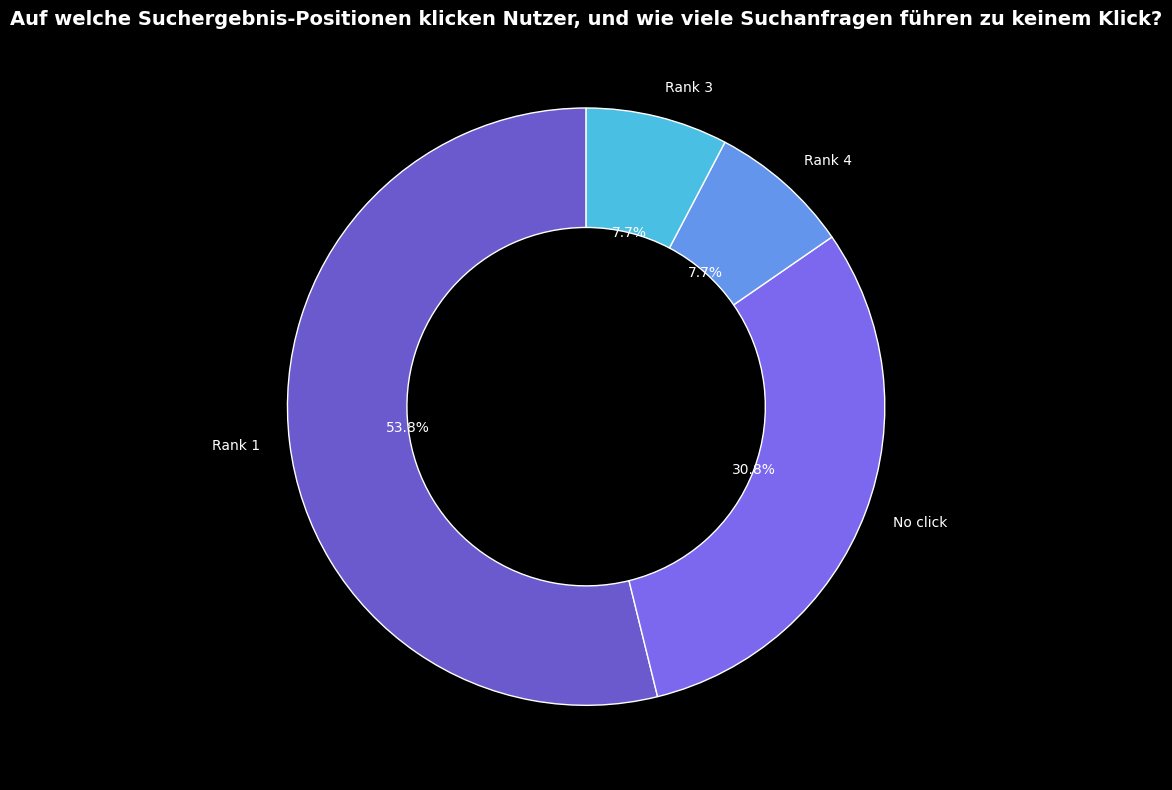

In [10]:
sql_query_10 = """
SELECT
    CASE
        WHEN search_click.item_rank IS NULL
            THEN 'No click'
        ELSE 'Rank ' || search_click.item_rank
    END AS click_position,

    COUNT(*) AS search_count

FROM food_preferences.search

LEFT JOIN food_preferences.search_click
    ON search.search_id = search_click.search_id

GROUP BY
    CASE
        WHEN search_click.item_rank IS NULL
            THEN 'No click'
        ELSE 'Rank ' || search_click.item_rank
    END

ORDER BY search_count DESC;
"""


with engine.connect() as connection:
    click_data = pd.read_sql_query(
        text(sql_query_10),
        connection
    )


display(click_data)


# Donut chart
plt.figure(figsize=(8, 8))

plt.pie(
    click_data["search_count"],
    labels=click_data["click_position"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "#6A5ACD",
        "#7B68EE",
        "#6495ED",
        "#48BFE3",
        "#9D4EDD"
    ],
    wedgeprops={
        "width": 0.40,
        "edgecolor": "white"
    }
)

plt.title(
    "Auf welche Suchergebnis-Positionen klicken Nutzer, und wie viele Suchanfragen führen zu keinem Klick?",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

,period_name,intention,search_count
0,abends,Planung,21740
1,abends,Lieferdienst,6585
2,abends,Frühstück/Kaffee,5476
3,morgens,Planung,7238
4,morgens,Frühstück/Kaffee,2040
5,morgens,Lieferdienst,1064
6,sonstige,Planung,21942
7,sonstige,Frühstück/Kaffee,5130
8,sonstige,Lieferdienst,4262


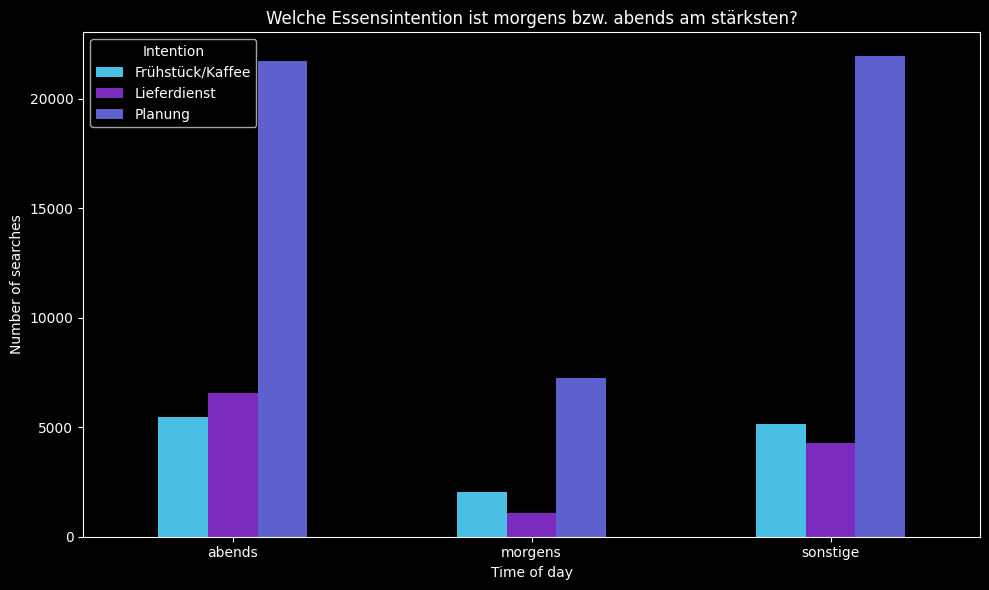

In [16]:
sql_query = """
SELECT
    t.period_name,
    c.category_name AS intention,
    e.search_count
FROM food_preferences.eating_pattern AS e
JOIN food_preferences.time_period AS t
    ON e.time_id = t.time_id
JOIN food_preferences.search_category AS c
    ON e.cat_id = c.cat_id
WHERE c.category_name <> 'Sonstiges'
ORDER BY t.period_name, e.search_count DESC;
"""

with engine.connect() as connection:
    data = pd.read_sql_query(text(sql_query), connection)

display(data)

chart_data = data.pivot(
    index="period_name",
    columns="intention",
    values="search_count"
).fillna(0)

chart_data.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#48BFE3", "#7B2CBF", "#5E60CE"]
)

plt.title("Welche Essensintention ist morgens bzw. abends am stärksten?")
plt.xlabel("Time of day")
plt.ylabel("Number of searches")
plt.xticks(rotation=0)
plt.legend(title="Intention")
plt.tight_layout()
plt.show()

,service_type,total_searches
0,recipe,838
1,delivery,613
2,breakfast,48


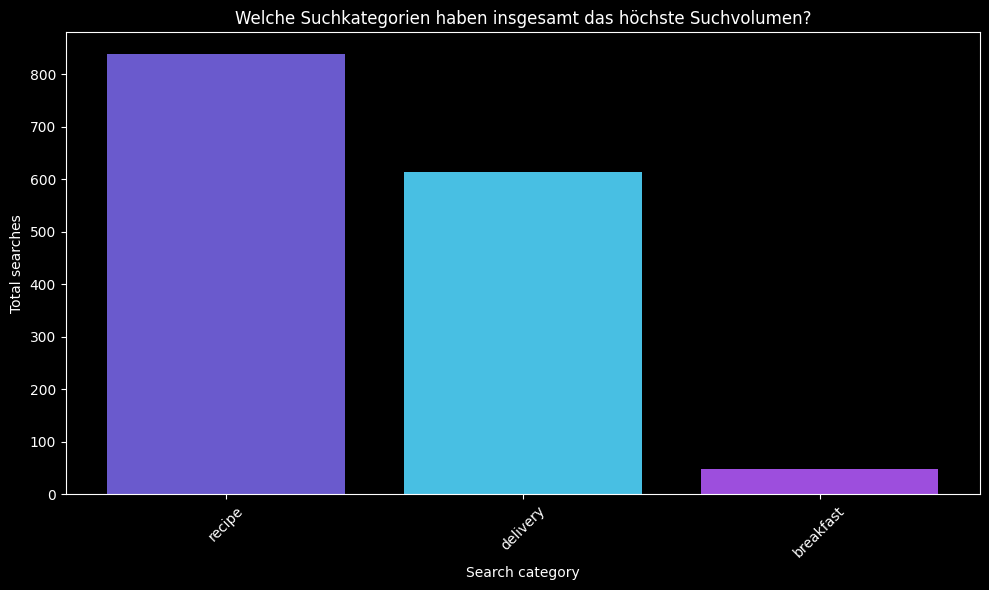

In [15]:
sql_query = """
SELECT
    c.service_type,
    SUM(s.anzahl_suchen) AS total_searches
FROM food_preferences.search_item AS s
JOIN food_preferences.search_category AS c
    ON s.cat_id = c.cat_id
GROUP BY c.service_type
ORDER BY total_searches DESC;
"""

with engine.connect() as connection:
    data = pd.read_sql_query(text(sql_query), connection)

display(data)

plt.figure(figsize=(10, 6))

plt.bar(
    data["service_type"],
    data["total_searches"],
    color=["#6A5ACD", "#48BFE3", "#9D4EDD",
           "#5390D9", "#7B2CBF", "#4EA8DE"]
)

plt.title("Welche Suchkategorien haben insgesamt das höchste Suchvolumen?")
plt.xlabel("Search category")
plt.ylabel("Total searches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,category_name,item_rank,click_count
0,General Search,1,7
1,General Search,3,1
2,General Search,4,1


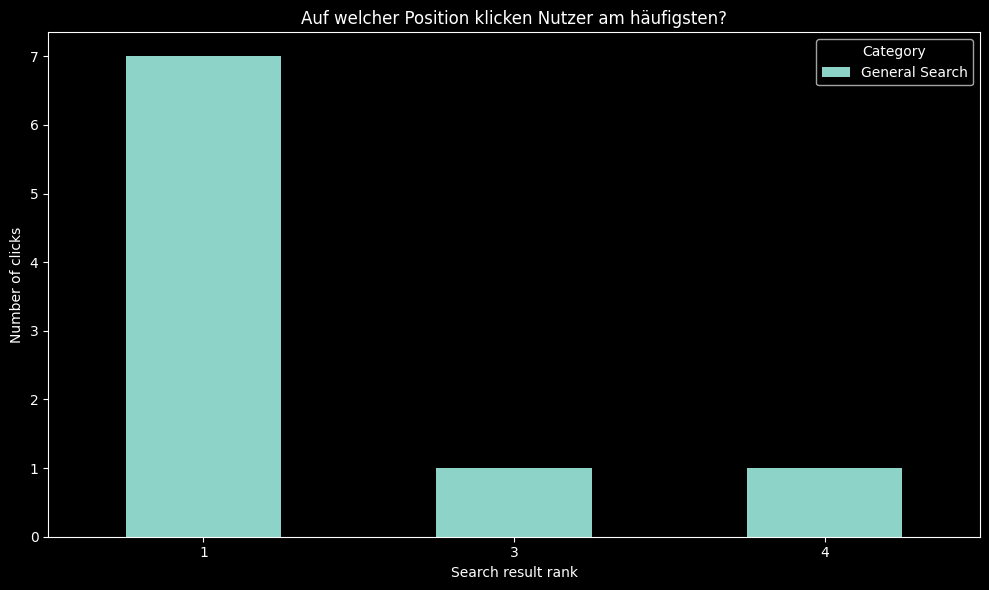

In [14]:
sql_query = """
SELECT
    c.category_name,
    sc.item_rank,
    COUNT(*) AS click_count
FROM food_preferences.search AS s
JOIN food_preferences.search_category AS c
    ON s.cat_id = c.cat_id
JOIN food_preferences.search_click AS sc
    ON s.search_id = sc.search_id
WHERE sc.item_rank IS NOT NULL
GROUP BY
    c.category_name,
    sc.item_rank
ORDER BY
    c.category_name,
    sc.item_rank;
"""

with engine.connect() as connection:
    data = pd.read_sql_query(text(sql_query), connection)

display(data)

chart_data = data.pivot(
    index="item_rank",
    columns="category_name",
    values="click_count"
).fillna(0)

chart_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Auf welcher Position klicken Nutzer am häufigsten?")
plt.xlabel("Search result rank")
plt.ylabel("Number of clicks")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.tight_layout()
plt.show()